In [1]:
import pandas as pd
import os 
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

In [ ]:
name_path = 'New_York_Air_Quality.csv'
folder_path = 'dataset'

file_path = os.path.join(folder_path, name_path)

df = pd.read_csv(file_path)
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
df.head(5)


,Date,City,CO,NO2,SO2,O3,PM2.5,PM10,AQI
0,2025-01-01 00:00:00+00:00,New York,304.0,49.6,8.2,17.0,10.0,11.8,26.375000
1,2025-01-01 01:00:00+00:00,New York,289.0,43.3,7.1,26.0,8.8,10.4,26.183334
2,2025-01-01 02:00:00+00:00,New York,269.0,34.5,5.6,38.0,7.4,8.8,25.924997
3,2025-01-01 03:00:00+00:00,New York,248.0,27.4,4.3,48.0,6.4,7.8,25.550000
4,2025-01-01 04:00:00+00:00,New York,224.0,23.4,3.5,54.0,6.0,7.4,25.066664


In [12]:
df['AQI_Stationary'] = df['AQI'].diff(24)

# ======================================================
# BƯỚC 2: QUAN TRỌNG - XÓA CÁC DÒNG NaN
# ======================================================
# 24 dòng đầu tiên sẽ là NaN. Ta phải xóa đi.
df_model = df.dropna().copy()

print(f"Dữ liệu gốc: {len(df)} dòng")
print(f"Dữ liệu sau khi xóa 24 dòng đầu: {len(df_model)} dòng")

# ======================================================
# BƯỚC 3: LƯU FILE CSV
# ======================================================
# Bạn nên lưu lại cả cột 'AQI' gốc để sau này còn dùng để cộng ngược (Invert)
columns_to_save = ['Date', 'City', 'AQI', 'AQI_Stationary'] 

# Nếu trong df có thêm các feature khác (Nhiệt độ, Độ ẩm...), bạn nhớ thêm vào list trên
df_model[columns_to_save].to_csv('AQI_Processed_For_Training.csv', index=False)

print("✅ Đã lưu file thành công: 'AQI_Processed_For_Training.csv'")
print("Đây là file bạn sẽ dùng để train XGBoost.")

Dữ liệu gốc: 8760 dòng
Dữ liệu sau khi xóa 24 dòng đầu: 8736 dòng
✅ Đã lưu file thành công: 'AQI_Processed_For_Training.csv'
Đây là file bạn sẽ dùng để train XGBoost.


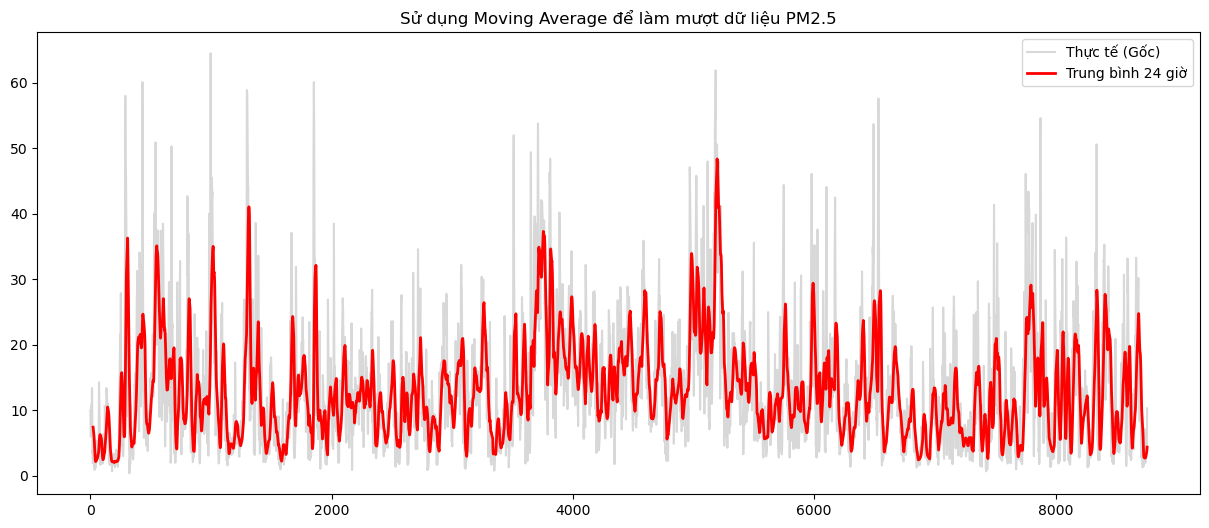

In [11]:
# 1. Tính trung bình trượt 6 giờ (Ngắn hạn - bắt biến động nhanh)
df['MA_6h'] = df['PM2.5'].rolling(window=6).mean()

# 2. Tính trung bình trượt 24 giờ (Dài hạn - nhìn xu hướng ngày)
df['MA_24h'] = df['PM2.5'].rolling(window=24).mean()

# --- TRỰC QUAN HÓA ---
plt.figure(figsize=(15, 6))
plt.plot(df['PM2.5'], label='Thực tế (Gốc)', alpha=0.3, color='gray') # Làm mờ dữ liệu gốc
#
plt.plot(df['MA_24h'], label='Trung bình 24 giờ', color='red', linewidth=2)

plt.title('Sử dụng Moving Average để làm mượt dữ liệu PM2.5')
plt.legend()
plt.show()


👉 Tìm thấy 8760 dòng dữ liệu cho New York.
⏳ Đang chạy STL (đợi xíu)...


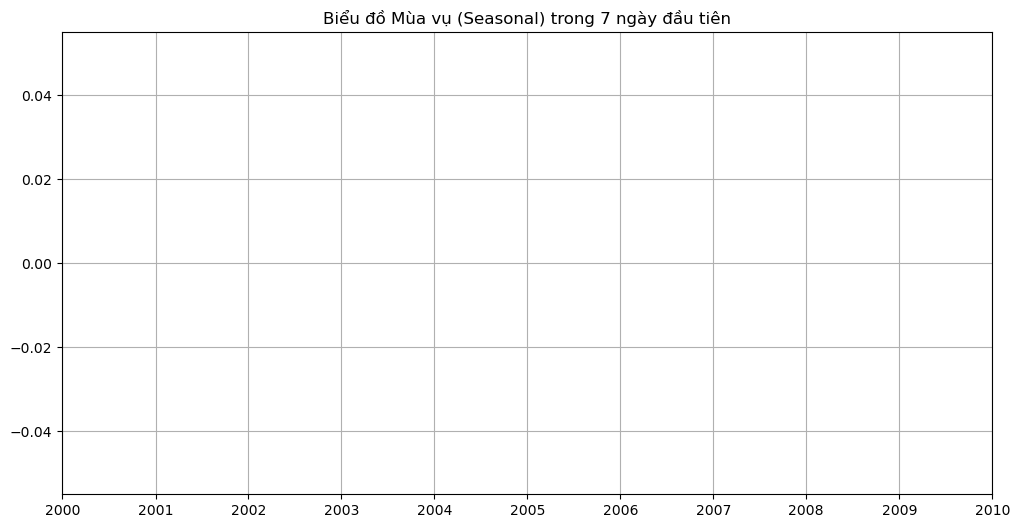

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

# ======================================================
# BƯỚC 1: XỬ LÝ DỮ LIỆU CHUNG (Chạy 1 lần cho chắc)
# ======================================================
# Xóa khoảng trắng thừa ở tên thành phố (quan trọng!)
df['City'] = df['City'].astype(str).str.strip()

# Chuyển đổi thời gian (xử lý utc=True vì dữ liệu bạn có +00:00)
df['Date'] = pd.to_datetime(df['Date'], utc=True)

# ======================================================
# BƯỚC 2: CHUẨN BỊ DỮ LIỆU CHO NEW YORK
# ======================================================
city_name = 'New York'
df_city = df[df['City'] == city_name].copy()

# --- Kiểm tra dữ liệu ---
print(f"👉 Tìm thấy {len(df_city)} dòng dữ liệu cho {city_name}.")

if len(df_city) == 0:
    print("❌ LỖI: Không có dữ liệu! Hãy kiểm tra lại tên thành phố.")
else:
    # 1. Xử lý trùng lặp thời gian (Gộp lại lấy trung bình)
    df_city = df_city.groupby('Date')['PM2.5'].mean()
    
    # 2. Đổi tần suất thành hàng giờ ('h' thường)
    df_city = df_city.asfreq('h')
    
    # 3. Nội suy dữ liệu thiếu (lấp đầy NaN)
    df_city = df_city.interpolate(method='time')

    # ======================================================
    # BƯỚC 3: CHẠY STL & VẼ HÌNH
    # ======================================================
    print("⏳ Đang chạy STL (đợi xíu)...")
    
    # --- QUAN TRỌNG: Gán kết quả vào biến tên là 'ket_qua' ---
    ket_qua = STL(df_city, period=24, robust=True).fit()

    # --- VẼ BIỂU ĐỒ (Chỉ 1 tuần đầu = 168 giờ) ---
    plt.figure(figsize=(12, 6))
    
    # Bây giờ biến 'ket_qua' đã có dữ liệu, vẽ sẽ không bị lỗi nữa
    plt.plot(ket_qua.seasonal[0:168], marker='o', markersize=3, color='green') 
    
    plt.title(f"Biểu đồ Mùa vụ (Seasonal) trong 7 ngày đầu - {city_name}")
    plt.grid(True)
    plt.ylabel("Độ lệch AQI (Seasonal)")
    plt.xlabel("Thời gian")
    plt.show()

    # In thử dữ liệu ra xem
    print("✅ Đã chạy xong! Dữ liệu mùa vụ 5 giờ đầu:")
    print(ket_qua.seasonal.head())
    
    # (Tùy chọn) Lưu kết quả vào DataFrame để dùng sau này
    # df_result = pd.DataFrame({'